In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


2026-03-31 17:24:52.829014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774977893.215177      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774977893.316092      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# =========================================================
# 2. REPRODUCIBILITY
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# =========================================================
# 3. PATHS
# =========================================================
CSV_PATH = "/kaggle/input/diabetic-retinopathy-detection/trainLabels.csv.zip"
IMG_DIR = "/kaggle/input/diabetic-retinopathy-train-unzipped/train"

In [4]:
# =========================================================
# 4. CONFIGURATION
# =========================================================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
THRESHOLD = 0.5
MAX_SAMPLES = 4000   # set to None if you want full dataset

In [5]:
# =========================================================
# 5. LOAD DATA
# =========================================================
df = pd.read_csv(CSV_PATH)

# Convert multiclass labels to binary:
# level = 0  -> No DR
# level > 0  -> DR Present
df["Label"] = (df["level"] > 0).astype(int)

# Create image file paths
df["filepath"] = df["image"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpeg"))

# Keep only rows where image exists
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print("Total images found:", len(df))
print(df["Label"].value_counts())

# Optional sampling for faster training
if MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df_class0 = df[df["Label"] == 0]
    df_class1 = df[df["Label"] == 1]

    n0 = int(MAX_SAMPLES * len(df_class0) / len(df))
    n1 = MAX_SAMPLES - n0

    df_class0 = df_class0.sample(n=min(n0, len(df_class0)), random_state=SEED)
    df_class1 = df_class1.sample(n=min(n1, len(df_class1)), random_state=SEED)

    df = pd.concat([df_class0, df_class1], axis=0)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nDataset size after sampling:", len(df))
print(df["Label"].value_counts())


Total images found: 35126
Label
0    25810
1     9316
Name: count, dtype: int64

Dataset size after sampling: 4000
Label
0    2939
1    1061
Name: count, dtype: int64


In [6]:
# =========================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# =========================================================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["Label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTraining class distribution before balancing:")
print(train_df["Label"].value_counts())


Train size: 2800
Validation size: 600
Test size: 600

Training class distribution before balancing:
Label
0    2057
1     743
Name: count, dtype: int64


In [7]:
# =========================================================
# 7. BALANCE TRAINING DATA ONLY
# =========================================================
def balance_train_dataframe(df_train, label_col="Label", seed=42):
    class0 = df_train[df_train[label_col] == 0]
    class1 = df_train[df_train[label_col] == 1]

    if len(class0) > len(class1):
        class1_upsampled = class1.sample(n=len(class0), replace=True, random_state=seed)
        balanced_df = pd.concat([class0, class1_upsampled], axis=0)
    else:
        class0_upsampled = class0.sample(n=len(class1), replace=True, random_state=seed)
        balanced_df = pd.concat([class0_upsampled, class1], axis=0)

    balanced_df = balanced_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df

train_balanced_df = balance_train_dataframe(train_df, label_col="Label", seed=SEED)

print("\nTraining class distribution after balancing:")
print(train_balanced_df["Label"].value_counts())


Training class distribution after balancing:
Label
0    2057
1    2057
Name: count, dtype: int64


In [8]:
# =========================================================
# 8. IMPORT MODEL BACKBONES
# =========================================================
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess

MODEL_CONFIGS = {
    "MobileNetV2": {
        "builder": MobileNetV2,
        "preprocess": mobilenet_preprocess
    },
    "EfficientNetB0": {
        "builder": EfficientNetB0,
        "preprocess": efficientnet_preprocess
    },
    "ResNet50": {
        "builder": ResNet50,
        "preprocess": resnet50_preprocess
    }
}

In [9]:
# =========================================================
# 9. DATA PIPELINE
# =========================================================
def decode_and_preprocess(path, label, preprocess_fn, training=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.08)
        image = tf.image.random_contrast(image, lower=0.95, upper=1.05)

    image = preprocess_fn(image)
    label = tf.cast(label, tf.float32)

    return image, label

def create_dataset(dataframe, preprocess_fn, batch_size=32, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["Label"].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(
        lambda x, y: decode_and_preprocess(x, y, preprocess_fn, training),
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset


In [10]:
# =========================================================
# 10. BUILD MODEL
# =========================================================
def build_model(model_name):
    base_model_fn = MODEL_CONFIGS[model_name]["builder"]

    base_model = base_model_fn(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [11]:
# =========================================================
# 11. TRAIN AND EVALUATE FUNCTION
# =========================================================
def train_and_evaluate(model_name, train_df, val_df, test_df):
    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    preprocess_fn = MODEL_CONFIGS[model_name]["preprocess"]

    train_ds = create_dataset(train_df, preprocess_fn, batch_size=BATCH_SIZE, training=True)
    val_ds = create_dataset(val_df, preprocess_fn, batch_size=BATCH_SIZE, training=False)
    test_ds = create_dataset(test_df, preprocess_fn, batch_size=BATCH_SIZE, training=False)

    model = build_model(model_name)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stopping],
        verbose=1
    )

    # Predictions
    y_true = test_df["Label"].values
    y_prob = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.0

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nResults for {model_name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "model_name": model_name,
        "model": model,
        "history": history.history,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


In [12]:
# =========================================================
# 12. TRAIN ALL 3 MODELS
# =========================================================
all_results = []

for model_name in MODEL_CONFIGS.keys():
    result = train_and_evaluate(
        model_name=model_name,
        train_df=train_balanced_df,
        val_df=val_df,
        test_df=test_df
    )
    all_results.append(result)


Training model: MobileNetV2


I0000 00:00:1774977950.593570      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


I0000 00:00:1774977963.013610      96 service.cc:148] XLA service 0x78e800002660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774977963.015338      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774977964.725295      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/129 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5347 - auc: 0.5525 - loss: 0.7679 - precision: 0.5390 - recall: 0.3028  

I0000 00:00:1774977969.271632      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


129/129 ━━━━━━━━━━━━━━━━━━━━ 93s 614ms/step - accuracy: 0.5370 - auc: 0.5542 - loss: 0.7455 - precision: 0.5434 - recall: 0.5548 - val_accuracy: 0.6750 - val_auc: 0.6340 - val_loss: 0.6175 - val_precision: 0.3989 - val_recall: 0.4465
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 67s 517ms/step - accuracy: 0.6003 - auc: 0.6486 - loss: 0.6738 - precision: 0.6014 - recall: 0.6073 - val_accuracy: 0.6867 - val_auc: 0.6544 - val_loss: 0.5990 - val_precision: 0.4099 - val_recall: 0.4151
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 70s 541ms/step - accuracy: 0.6308 - auc: 0.6819 - loss: 0.6502 - precision: 0.6288 - recall: 0.6168 - val_accuracy: 0.6733 - val_auc: 0.6692 - val_loss: 0.6026 - val_precision: 0.4000 - val_recall: 0.4654
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 68s 527ms/step - accuracy: 0.6451 - auc: 0.7055 - loss: 0.6270 - precision: 0.6565 - recall: 0.6081 - val_accuracy: 0.6200 - val_auc: 0.6658 - val_loss: 0.6502 - val_precision: 0.3668 - val_recall: 0.5975

Results for MobileNetV2
Accuracy 

In [13]:
# =========================================================
# 13. CREATE RESULTS TABLE
# =========================================================
results_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1-Score": r["f1_score"],
        "AUC": r["auc"]
    }
    for r in all_results
])

print("\nFinal Results:")
print(results_df)

# Save results
results_df.to_csv("model_comparison_results_224.csv", index=False)



Final Results:
            Model  Accuracy  Precision    Recall  F1-Score       AUC
0     MobileNetV2  0.676667   0.395210  0.415094  0.404908  0.637260
1  EfficientNetB0  0.685000   0.418478  0.484277  0.448980  0.670104
2        ResNet50  0.690000   0.433498  0.553459  0.486188  0.689029


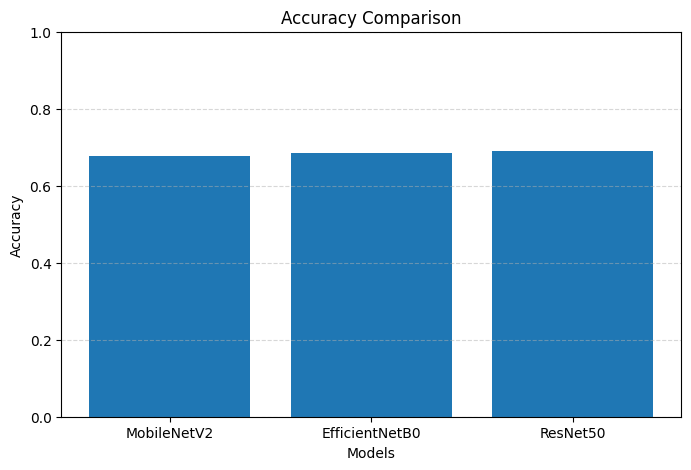

In [14]:
# =========================================================
# 14. BAR GRAPH - ACCURACY
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


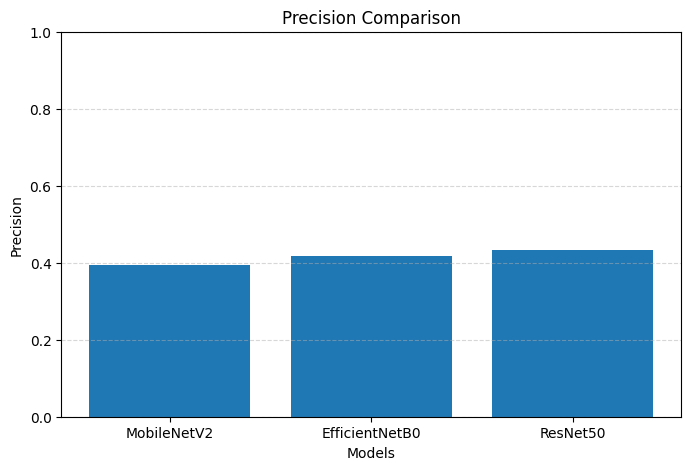

In [15]:

# =========================================================
# 15. BAR GRAPH - PRECISION
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Precision Comparison")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


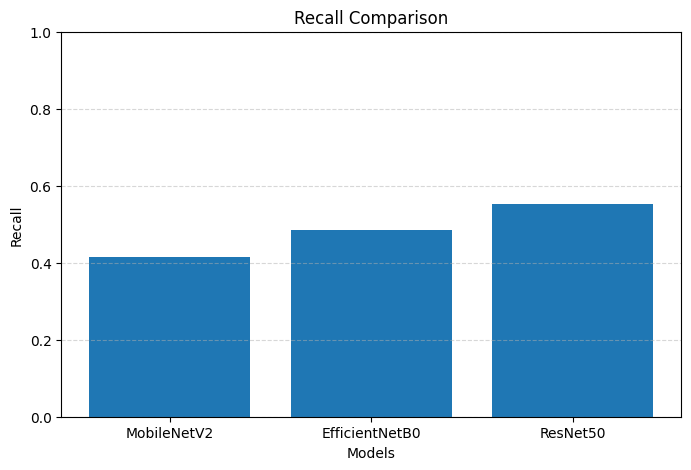

In [16]:
# =========================================================
# 16. BAR GRAPH - RECALL
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


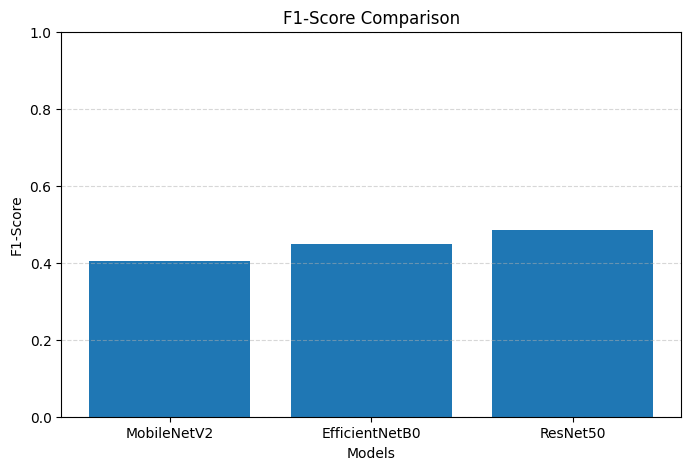

In [17]:
# =========================================================
# 17. BAR GRAPH - F1 SCORE
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["F1-Score"])
plt.title("F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

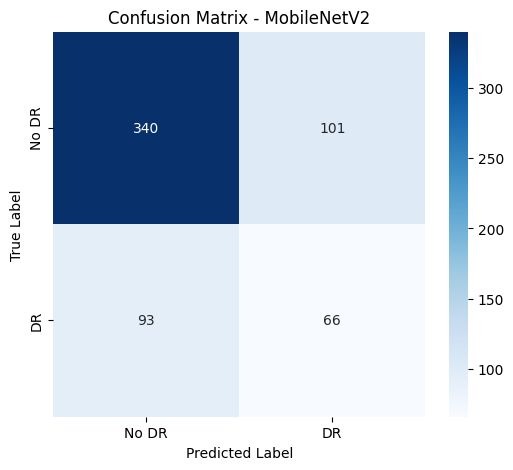

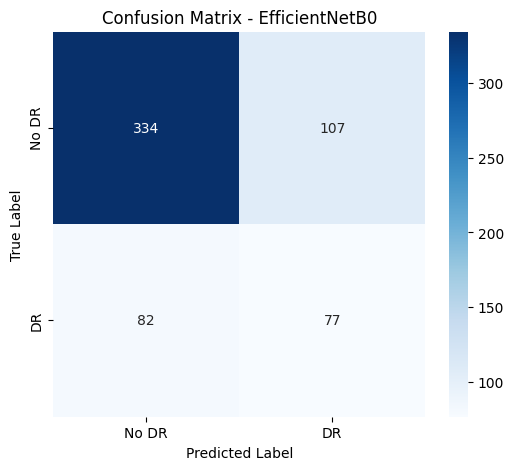

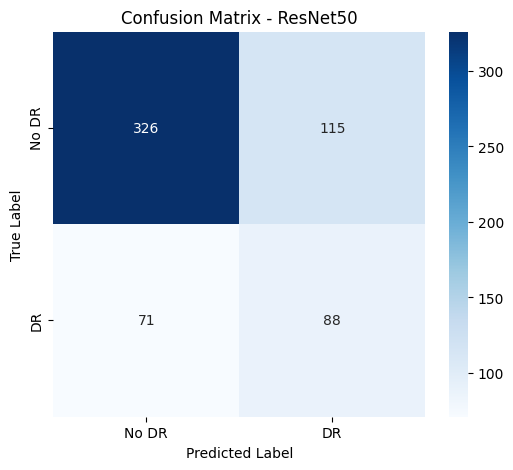

In [18]:
# =========================================================
# 18. CONFUSION MATRICES FOR ALL MODELS
# =========================================================
for result in all_results:
    cm = result["confusion_matrix"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No DR", "DR"],
        yticklabels=["No DR", "DR"]
    )
    plt.title(f"Confusion Matrix - {result['model_name']}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()